In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-24 10:02:23.987563


# Gaussian mixture model

GMM on a subset of the data as analysis strategy for separating signal and noise

In [13]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [14]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150
#sc.set_figure_params(scanpy=True)

warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [15]:
base_dir = Path("/home/workspace/projects/drg")
input_dir = base_dir / "data/h5ad/export_02/03_annotated"

### Read and process adata

In [52]:
adata = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))
adata_ref = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))

# have to use the version of the dataset that has the transgenes to draw positive and negative signal

#bdata = sc.read_h5ad(os.path.join(input_dir, 'ModelB_whole_noTG_annotated.h5ad'))
# this is the dataset with adata.var subsetted to 475, 5 transgenes witheld


In [53]:
transgenes = ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']

In [54]:
adata.X[:5, :5].toarray()

array([[ 0.       ,  8.659507 ,  0.       ,  8.659507 ,  0.       ],
       [ 7.125473 ,  9.021909 ,  6.028468 ,  9.2450285,  0.       ],
       [ 6.24855  ,  6.24855  ,  7.85644  ,  8.811713 ,  0.       ],
       [ 0.       ,  7.644289 ,  0.       ,  0.       ,  0.       ],
       [ 0.       ,  9.205453 ,  0.       , 10.016328 ,  0.       ]],
      dtype=float32)

In [58]:
adata.X = adata.layers['counts'].copy()
adata_ref.X = adata_ref.layers['counts'].copy()

# Gaussian Mixture Models

## Raw counts
* Gaussian Mixture Models (GMMs) were fitted directly on raw count values (adata[:, g].X).
* No transformation or normalization applied.
* Thresholding and high-expression classification were both based on raw counts.
* Dual-positive identification was based on raw thresholds.
* Plot and axis labels correctly reflect raw count scale.

In [59]:
genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 3
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)



EGFP_Seq1: high_cluster_mean=11.75, thr=118.36, n_hi=9 (0.0093%)
tdTomato_Seq2: high_cluster_mean=4.36, thr=34.17, n_hi=13 (0.0134%)

Ultra-strict dual positives: 0/97027 (0.0000%)


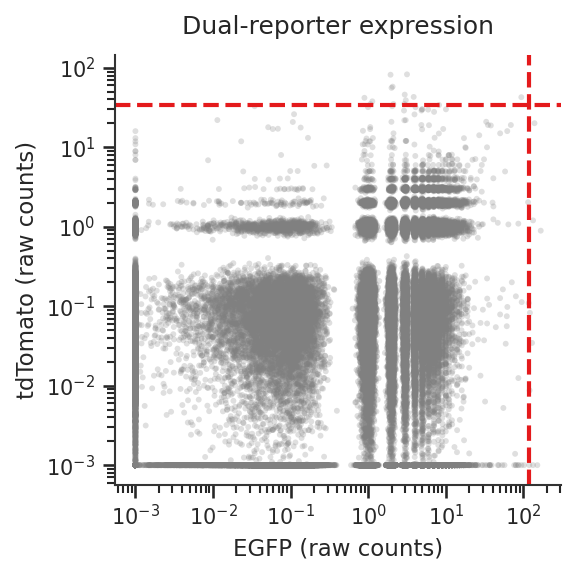

In [63]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 3
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

for g in genes:
    x = to_dense(adata[:, g].X).reshape(-1, 1)  # raw counts only

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x)
    probs = gmm.predict_proba(x)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    high_mask = probs[:, high_cluster] > prob_threshold
    x_high = x[high_mask].ravel()

    thr_expr = np.percentile(x_high, within_cluster_q * 100) if x_high.size > 0 else means[high_cluster]
    hi_mask = (high_mask.ravel()) & (x.ravel() > thr_expr)

    adata.obs[f"{g}_hi"] = hi_mask

    gmm_results[g] = {
        "gmm": gmm,
        "x": x.ravel(),
        "means": means,
        "covars": gmm.covariances_.flatten(),
        "weights": gmm.weights_.flatten(),
        "high_cluster": high_cluster,
        "high_mask": high_mask.ravel(),
        "thr_expr": thr_expr,
    }

    print(f"{g}: high_cluster_mean={means[high_cluster]:.2f}, "
          f"thr={thr_expr:.2f}, n_hi={hi_mask.sum()} ({100*hi_mask.mean():.4f}%)")

# Dual-high label
adata.obs['EGFP_tdTomato_dual_hi'] = adata.obs['EGFP_Seq1_hi'] & adata.obs['tdTomato_Seq2_hi']
n_dual = adata.obs['EGFP_tdTomato_dual_hi'].sum()
print(f"\nUltra-strict dual positives: {n_dual}/{adata.n_obs} ({100*n_dual/adata.n_obs:.4f}%)")

# Plot
# Extract raw counts and jitter
x_egfp = to_dense(adata[:, "EGFP_Seq1"].X)
x_td   = to_dense(adata[:, "tdTomato_Seq2"].X)
dual   = adata.obs["EGFP_tdTomato_dual_hi"]

rng = np.random.default_rng(0)
x_egfp_j = np.clip(x_egfp + rng.normal(scale=0.1, size=x_egfp.shape), 1e-3, None)
x_td_j   = np.clip(x_td   + rng.normal(scale=0.1, size=x_td.shape),   1e-3, None)

sns.set_theme(style="ticks")
plt.rcParams.update({
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1,
    "font.size": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(figsize=(4, 4), dpi=150)

# Background points
ax.scatter(
    x_egfp_j, x_td_j,
    s=8, color="gray", alpha=0.25, edgecolor="none"
)

# Dual-high cells
ax.scatter(
    x_egfp_j[dual], x_td_j[dual],
    s=60, facecolors=(1, 0, 0, 0.4), edgecolors="black", linewidths=0.8,
    label="Dual-high cells"
)

# Thresholds
ax.axvline(gmm_results["EGFP_Seq1"]["thr_expr"], color="#e41a1c", ls="--", lw=2)
ax.axhline(gmm_results["tdTomato_Seq2"]["thr_expr"], color="#e41a1c", ls="--", lw=2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("EGFP (raw counts)")
ax.set_ylabel("tdTomato (raw counts)")
ax.set_title("Dual-reporter expression", pad=10)
sns.despine()
plt.tight_layout()
plt.show()

## GMM all log1p

EGFP_Seq1: high_cluster_mean=1.57, thr=2.77, n_hi=358 (0.3690%)
tdTomato_Seq2: high_cluster_mean=1.25, thr=2.91, n_hi=42 (0.0433%)

Dual positives (log1p thresholding): 6/97027 (0.0062%)


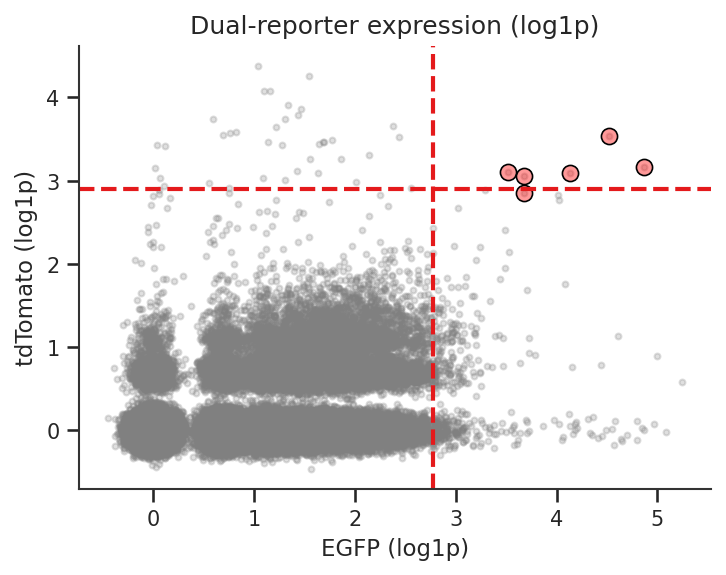

In [68]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 3
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

for g in genes:
    x_raw = to_dense(adata[:, g].X)
    x_log1p = np.log1p(x_raw).reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log1p)
    probs = gmm.predict_proba(x_log1p)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    high_mask = probs[:, high_cluster] > prob_threshold
    x_high_log = x_log1p[high_mask].ravel()

    thr_expr_log = np.percentile(x_high_log, within_cluster_q * 100) if x_high_log.size > 0 else means[high_cluster]
    hi_mask = high_mask & (x_log1p.ravel() > thr_expr_log)

    adata.obs[f"{g}_hi"] = hi_mask

    gmm_results[g] = {
        "gmm": gmm,
        "x": x_log1p.ravel(),
        "means": means,
        "covars": gmm.covariances_.flatten(),
        "weights": gmm.weights_.flatten(),
        "high_cluster": high_cluster,
        "high_mask": high_mask,
        "thr_expr": thr_expr_log,
    }

    print(f"{g}: high_cluster_mean={means[high_cluster]:.2f}, "
          f"thr={thr_expr_log:.2f}, n_hi={hi_mask.sum()} ({100*hi_mask.mean():.4f}%)")

# Dual-high label
adata.obs['EGFP_tdTomato_dual_hi'] = adata.obs['EGFP_Seq1_hi'] & adata.obs['tdTomato_Seq2_hi']
n_dual = adata.obs['EGFP_tdTomato_dual_hi'].sum()
print(f"\nDual positives (log1p thresholding): {n_dual}/{adata.n_obs} ({100*n_dual/adata.n_obs:.4f}%)")

# === Plotting ===
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

x_egfp_log = gmm_results["EGFP_Seq1"]["x"]
x_td_log   = gmm_results["tdTomato_Seq2"]["x"]
dual       = adata.obs["EGFP_tdTomato_dual_hi"].values

rng = np.random.default_rng(0)
x_egfp_log_j = x_egfp_log + rng.normal(scale=0.1, size=x_egfp_log.shape)
x_td_log_j   = x_td_log   + rng.normal(scale=0.1, size=x_td_log.shape)

sns.set_theme(style="ticks")
plt.rcParams.update({
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1,
    "font.size": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(figsize=(5, 4), dpi=150)

ax.scatter(x_egfp_log_j, x_td_log_j, s=8, color="gray", alpha=0.25)
ax.scatter(x_egfp_log_j[dual], x_td_log_j[dual], s=60, facecolors=(1, 0, 0, 0.4),
           edgecolors="black", linewidths=0.8, label="Dual-high cells")
ax.axvline(gmm_results["EGFP_Seq1"]["thr_expr"], color="#e41a1c", ls="--", lw=2)
ax.axhline(gmm_results["tdTomato_Seq2"]["thr_expr"], color="#e41a1c", ls="--", lw=2)
ax.set_xlabel("EGFP (log1p)")
ax.set_ylabel("tdTomato (log1p)")
ax.set_title("Dual-reporter expression (log1p)")
sns.despine()
plt.tight_layout()
plt.show()

## GMM on log1p-transformed raw counts (hybrid: raw thresholding, no normalization)
* GMMs were fitted on log1p-transformed counts (np.log1p(x_raw)).
* Thresholding was still applied in raw count space (using original x_raw).
* High-expression classification combined log1p-based model with raw thresholds.
* Plot and axis labels reflect raw count scale.
* This hybrid method provided better identification of validated dual-high cells.

EGFP_Seq1: high_cluster_mean_log=1.57, thr_log=2.77, n_hi=358 (0.3690%)
tdTomato_Seq2: high_cluster_mean_log=1.25, thr_log=2.91, n_hi=42 (0.0433%)

Dual positives (log1p): 6/97027 (0.0062%)


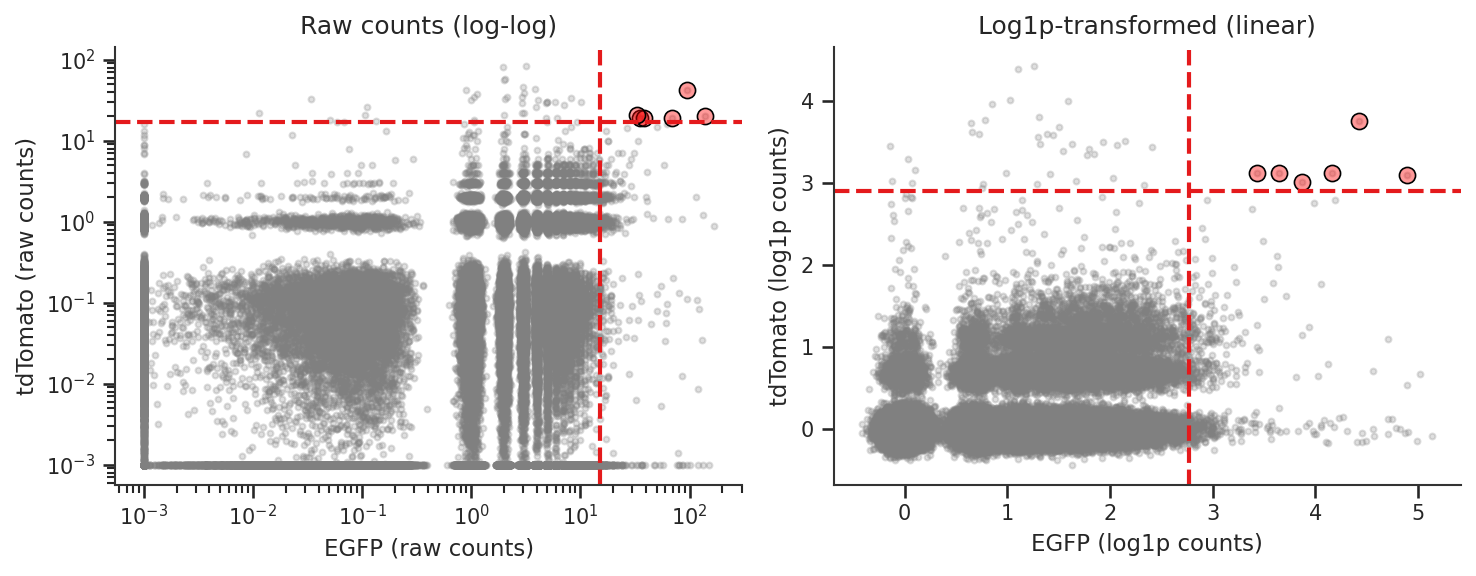

In [69]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 3
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

for g in genes:
    x_raw = to_dense(adata[:, g].X)
    x_log1p = np.log1p(x_raw).reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log1p)
    probs = gmm.predict_proba(x_log1p)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    high_mask = probs[:, high_cluster] > prob_threshold
    x_high_log = x_log1p.ravel()[high_mask]

    thr_expr_log = np.percentile(x_high_log, within_cluster_q * 100) if x_high_log.size > 0 else means[high_cluster]
    hi_mask = high_mask & (x_log1p.ravel() > thr_expr_log)

    adata.obs[f"{g}_hi"] = hi_mask

    gmm_results[g] = {
        "gmm": gmm,
        "x_raw": x_raw,
        "x_log": x_log1p.ravel(),
        "means": means,
        "covars": gmm.covariances_.flatten(),
        "weights": gmm.weights_.flatten(),
        "high_cluster": high_cluster,
        "high_mask": high_mask,
        "thr_expr_log": thr_expr_log,
    }

    print(f"{g}: high_cluster_mean_log={means[high_cluster]:.2f}, "
          f"thr_log={thr_expr_log:.2f}, n_hi={hi_mask.sum()} ({100*hi_mask.mean():.4f}%)")

# Dual-high label
adata.obs['EGFP_tdTomato_dual_hi'] = adata.obs['EGFP_Seq1_hi'] & adata.obs['tdTomato_Seq2_hi']
n_dual = adata.obs['EGFP_tdTomato_dual_hi'].sum()
print(f"\nDual positives (log1p): {n_dual}/{adata.n_obs} ({100*n_dual/adata.n_obs:.4f}%)")

# === Plot ===
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

x_egfp_raw = gmm_results["EGFP_Seq1"]["x_raw"]
x_td_raw   = gmm_results["tdTomato_Seq2"]["x_raw"]
x_egfp_log = gmm_results["EGFP_Seq1"]["x_log"]
x_td_log   = gmm_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gmm_results["EGFP_Seq1"]["thr_expr_log"]
thr_td_log   = gmm_results["tdTomato_Seq2"]["thr_expr_log"]
dual         = adata.obs["EGFP_tdTomato_dual_hi"].values

rng = np.random.default_rng(0)
x_egfp_raw_j = np.clip(x_egfp_raw + rng.normal(scale=0.1, size=x_egfp_raw.shape), 1e-3, None)
x_td_raw_j   = np.clip(x_td_raw   + rng.normal(scale=0.1, size=x_td_raw.shape),   1e-3, None)
x_egfp_log_j = x_egfp_log + rng.normal(scale=0.1, size=x_egfp_log.shape)
x_td_log_j   = x_td_log   + rng.normal(scale=0.1, size=x_td_log.shape)

sns.set_theme(style="ticks")
plt.rcParams.update({
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1,
    "font.size": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

# Plot 1: Raw counts (log-log)
ax1.scatter(x_egfp_raw_j, x_td_raw_j, s=8, color="gray", alpha=0.25)
ax1.scatter(x_egfp_raw_j[dual], x_td_raw_j[dual], s=60, facecolors=(1, 0, 0, 0.4),
            edgecolors="black", linewidths=0.8, label="Dual-high cells")
ax1.axvline(np.expm1(thr_egfp_log), color="#e41a1c", ls="--", lw=2)
ax1.axhline(np.expm1(thr_td_log), color="#e41a1c", ls="--", lw=2)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("EGFP (raw counts)")
ax1.set_ylabel("tdTomato (raw counts)")
ax1.set_title("Raw counts (log-log)")

# Plot 2: Log1p-transformed (linear)
ax2.scatter(x_egfp_log_j, x_td_log_j, s=8, color="gray", alpha=0.25)
ax2.scatter(x_egfp_log_j[dual], x_td_log_j[dual], s=60, facecolors=(1, 0, 0, 0.4),
            edgecolors="black", linewidths=0.8, label="Dual-high cells")
ax2.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax2.axhline(thr_td_log, color="#e41a1c", ls="--", lw=2)
ax2.set_xlabel("EGFP (log1p counts)")
ax2.set_ylabel("tdTomato (log1p counts)")
ax2.set_title("Log1p-transformed (linear)")

sns.despine()
plt.tight_layout()
plt.show()

# Negative binomial